## Predicting Listing Gains in the Indian IPO Market Using PyTorch

In this project, we'll will build a binary classification model using PyTorch to predict whether an IPO will generate listing gains or not by analyzing Initial Public Offerings (IPOs) in the Indian market.

The dataset contains historical information on IPOs in the Indian market, sourced from [moneycontrol](https://www.moneycontrol.com/ipo/ipo-historic-table?classic=true).

**Data Dictionary**
The dataset contains the following columns:

`Date`: date when the IPO was listed

`IPOName`: name of the IPO

`Issue_Size`: size of the IPO issue, in INR Crores

`Subscription_QIB`: number of times the IPO was subscribed by QIB (Qualified Institutional Buyer) investors

`Subscription_HNI`: number of times the IPO was subscribed by HNI (High Networth Individual) investors

`Subscription_RII`: number of times the IPO was subscribed by RII (Retail Individual Investors)

`Subscription_Total`: total number of times the IPO was subscribed overall

`Issue_Price`: the price in INR at which the IPO was issued

`Listing_Gains_Percent`: percentage gain in the listing price over the issue price (this becomes our target!)

The `Listing_Gains_Percent` column is particularly important since it will become the foundation for our binary classification target. We want to understand its range and distribution before we transform it into a binary variable.


## Explore the dataset

In [1]:
# import necessary library
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, confusion_matrix
import copy

In [2]:
# Load the dataset in df variable
df = pd.read_csv("../../dataset/Indian_IPO_Market_Data.csv")
df.head()

,Date,IPOName,Issue_Size,Subscription_QIB,Subscription_HNI,Subscription_RII,Subscription_Total,Issue_Price,Listing_Gains_Percent
0,03/02/10,Infinite Comp,189.80,48.44,106.02,11.08,43.22,165,11.82
1,08/02/10,Jubilant Food,328.70,59.39,51.95,3.79,31.11,145,-84.21
2,15/02/10,Syncom Health,56.25,0.99,16.60,6.25,5.17,75,17.13
3,15/02/10,Vascon Engineer,199.80,1.12,3.65,0.62,1.22,165,-11.28
4,19/02/10,Thangamayil,0.00,0.52,1.52,2.26,1.12,75,-5.20


In [3]:
df.tail()

,Date,IPOName,Issue_Size,Subscription_QIB,Subscription_HNI,Subscription_RII,Subscription_Total,Issue_Price,Listing_Gains_Percent
314,26/08/22,Syrma SGS,840.13,42.42,7.13,2.84,15.59,220,42.30
315,06/09/22,Dreamfolks Serv,562.10,27.48,14.18,24.19,23.25,326,41.92
316,15/09/22,TMB,792.00,0.51,1.77,3.44,1.39,525,-3.15
317,26/09/22,Harsha Engineer,755.00,113.82,40.36,12.44,47.19,330,47.24
318,17/10/22,Electronics Mar,500.00,58.81,15.39,8.27,24.23,59,43.14


In [4]:
df.shape

(319, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   319 non-null    object 
 1   IPOName                319 non-null    object 
 2   Issue_Size             319 non-null    float64
 3   Subscription_QIB       319 non-null    float64
 4   Subscription_HNI       319 non-null    float64
 5   Subscription_RII       319 non-null    float64
 6   Subscription_Total     319 non-null    float64
 7   Issue_Price            319 non-null    int64  
 8   Listing_Gains_Percent  319 non-null    float64
dtypes: float64(6), int64(1), object(2)
memory usage: 22.6+ KB


In [6]:
df['Listing_Gains_Percent'].describe()

count    319.000000
mean       4.742696
std       47.650946
min      -97.150000
25%      -11.555000
50%        1.810000
75%       25.310000
max      270.400000
Name: Listing_Gains_Percent, dtype: float64

In [7]:
df.describe()

,Issue_Size,Subscription_QIB,Subscription_HNI,Subscription_RII,Subscription_Total,Issue_Price,Listing_Gains_Percent
count,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000
mean,1192.859969,25.684138,70.091379,8.561599,27.447147,375.128527,4.742696
std,2384.643786,40.716782,142.454416,14.508670,48.772203,353.897614,47.650946
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-97.150000
25%,169.005000,1.150000,1.255000,1.275000,1.645000,119.000000,-11.555000
50%,496.250000,4.940000,5.070000,3.420000,4.930000,250.000000,1.810000
75%,1100.000000,34.635000,62.095000,8.605000,33.395000,536.000000,25.310000
max,21000.000000,215.450000,958.070000,119.440000,326.490000,2150.000000,270.400000


The dataset contains 319 observation of ipo listing over the period of `2010 to 2022` with 9 features columns.

- All the features have no missing value so we can procede with the anayis.
- The mean listing gain is `4.72%` which show an overall positive performance.
- While the median is `1.81%` which indicate the heavy lifting is done by some of the high performing company with larger initial gains.
- We can just choose the threshold as postive and negative values for the binary classification problem.
- We can see the issue size of 0 here might be the error so we will analyze that column.

In [8]:
df[df['Issue_Size'] == 0]

,Date,IPOName,Issue_Size,Subscription_QIB,Subscription_HNI,Subscription_RII,Subscription_Total,Issue_Price,Listing_Gains_Percent
4,19/02/10,Thangamayil,0.0,0.52,1.52,2.26,1.12,75,-5.20
41,08/10/10,Electrosteel St,0.0,5.86,28.58,6.19,8.23,11,2.27
102,06/12/12,Tara Jewels,0.0,1.49,3.10,2.05,1.98,230,-0.02
282,15/11/21,Sigachi Ind,0.0,42.15,78.82,41.26,49.56,163,270.40


The Issue_Size might be zeros because the ipos are smaller in amounts like in lakhs or there are errors in recording. so we will remove the rows with these observations.

In [9]:
df = df[df['Issue_Size'] != 0]
df.describe()

,Issue_Size,Subscription_QIB,Subscription_HNI,Subscription_RII,Subscription_Total,Issue_Price,Listing_Gains_Percent
count,315.000000,315.000000,315.000000,315.000000,315.000000,315.000000,315.000000
mean,1208.007397,25.851492,70.625810,8.506000,27.602381,378.371429,3.953873
std,2395.956871,40.901730,143.235782,14.473959,49.010199,354.836463,45.538441
min,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-97.150000
25%,179.815000,1.150000,1.210000,1.220000,1.645000,120.000000,-11.600000
50%,500.000000,4.940000,5.070000,3.420000,4.930000,252.000000,1.810000
75%,1107.000000,34.635000,62.095000,8.605000,33.395000,541.500000,25.310000
max,21000.000000,215.450000,958.070000,119.440000,326.490000,2150.000000,185.000000


## Target Engineering & Business Understanding

We transform our continuous Listing_Gains_Percent variable into something more actionable:  should we invest in this IPO or not?

In the investment world, this binary approach makes perfect sense. Even a small positive return (like 2% listing gains) means the IPO was worth investing in, while any loss (negative gains) means it wasn't

In [10]:
# Create a new binary target variable: Listing_Gains_Profit
df['Listing_Gains_Profit'] = 0
df.loc[df['Listing_Gains_Percent'] > 0, 'Listing_Gains_Profit'] = 1
df.head()

,Date,IPOName,Issue_Size,Subscription_QIB,Subscription_HNI,Subscription_RII,Subscription_Total,Issue_Price,Listing_Gains_Percent,Listing_Gains_Profit
0,03/02/10,Infinite Comp,189.80,48.44,106.02,11.08,43.22,165,11.82,1
1,08/02/10,Jubilant Food,328.70,59.39,51.95,3.79,31.11,145,-84.21,0
2,15/02/10,Syncom Health,56.25,0.99,16.60,6.25,5.17,75,17.13,1
3,15/02/10,Vascon Engineer,199.80,1.12,3.65,0.62,1.22,165,-11.28,0
5,23/02/10,Aqua Logistics,150.00,0.26,5.07,3.00,1.94,220,-88.88,0


In [11]:
# Examine the distribution of the new target variable
df['Listing_Gains_Profit'].value_counts(normalize = True)

Listing_Gains_Profit
1    0.546032
0    0.453968
Name: proportion, dtype: float64

We can observe that `54.6%` are profitable listing gains.
We have a balanced dataset which will make the anaysis more easier.


### Feature Selection
we will exclude some of the columns which might not be necessary for this task.

`Date`: Athough date column might have short term impact, it is neccessarily good for ipo.

`IPOName`: Names of the company are not a good indicator.

`Listing_Gains_Percent`: Since we create , `Listing_Gains_Profit` for target variable using this columns. We have to remove this column, as it will be considered cheating using this column.

`Listing_Gains_Percent`: Since it is our target variable, we will not use it as predictor variable.


In [12]:
target_variable = df['Listing_Gains_Profit']
predictors = df.drop(['Date ', 'IPOName', 'Listing_Gains_Percent', 'Listing_Gains_Profit'], axis = 1)


## Visual Data Exploration¶
The goal of this exploratory analysis is to uncover patterns that could help your investment firm make better decisions. Do larger IPOs tend to be more successful? Does high subscription demand predict listing gains? Are there relationships between different types of investor interest?

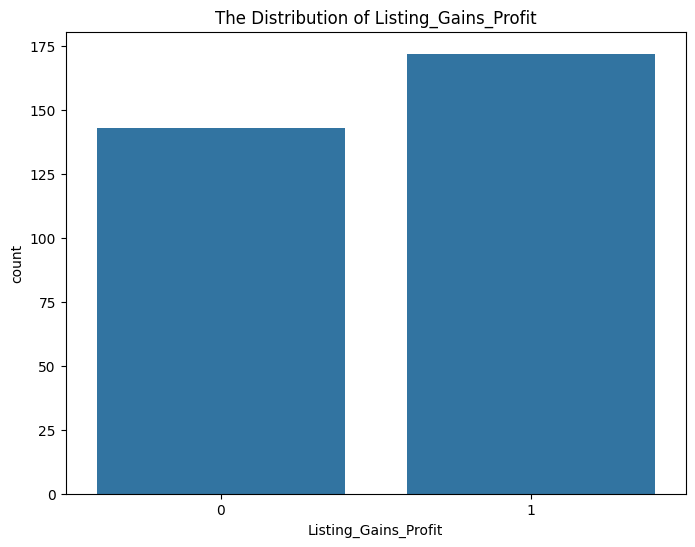

In [13]:
# plot showing the distribution of target variable
plt.figure(figsize=(8, 6))
sns.countplot(data = df, x = df['Listing_Gains_Profit'])
plt.title('The Distribution of Listing_Gains_Profit')
plt.show()

We have a fairly balanced dataset: 174 profitable vs 145 unprofitable IPOs

### Feature Distribution
Examine the distributions of potential feature variables.

In [14]:
print(predictors.columns)

Index(['Issue_Size', 'Subscription_QIB', 'Subscription_HNI',
       'Subscription_RII', 'Subscription_Total', 'Issue_Price'],
      dtype='object')


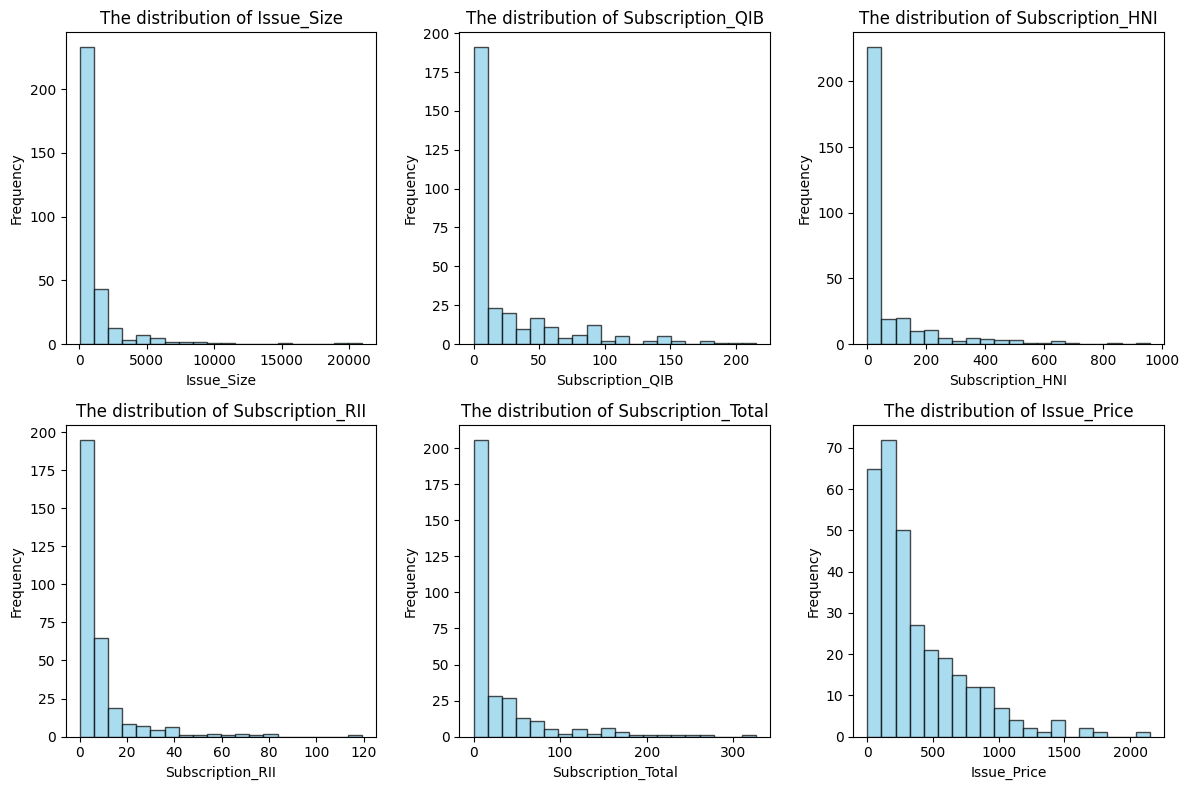

In [15]:
fig, axes = plt.subplots(2, 3, figsize  = (12,8))
axes = axes.flatten()
for i, cols in enumerate(predictors.columns):
    axes[i].hist(df[cols],bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    axes[i].set_title(f"The distribution of {cols}")
    axes[i].set_xlabel(cols)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Looking at these distribution plots, we can see a clear story about how IPOs behave in this market.

Five of our six features show the same dramatic pattern: most values cluster heavily in that first bin on the left, then drop off sharply as we move right. This tells us that most IPOs in our dataset have relatively low subscription rates, smaller issue sizes, and modest metrics overall. The sparse bins on the right represent the few IPOs that had massive oversubscription or unusually large issue sizes.

Think about what this means: a typical IPO might get 2x or 5x subscription, but a few outliers get 50x or 100x oversubscribed. Most companies raise moderate amounts, but a few giants dominate the right side of the distribution.

`Issue_Price` shows a bit more spread, but it's still right-skewed. Most IPOs price themselves in the lower to mid range, with fewer companies commanding premium pricing.

This kind of distribution can create a challenge for our model. Those extreme values on the right could dominate the learning process, making the model focus too much on rare outliers instead of learning the patterns that apply to most IPOs. The model might think that only massively oversubscribed IPOs succeed, missing the subtler patterns in the typical cases.

But that's okay because we're going to scale our data, which will put all features on the same playing field and prevent those outliers from overwhelming our model's learning process.

### How Do Features Relate to IPO Success?
 We want to see if profitable IPOs look different from unprofitable ones across our features.

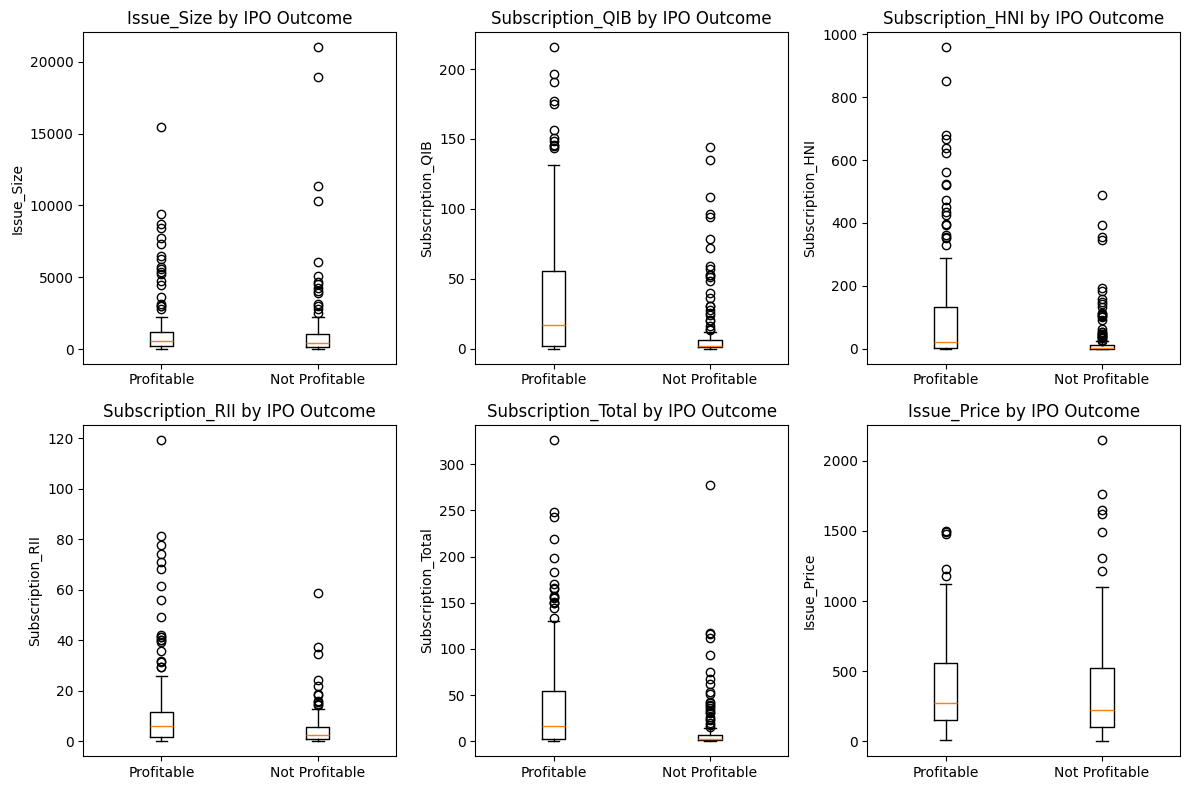

In [16]:
# Let's compare profitable and non-profitable ipos across features

fig, axes = plt.subplots(2, 3, figsize=(12,8))
axes = axes.flatten()
for i, cols in enumerate(predictors.columns):
    profitable_data = df[df['Listing_Gains_Profit'] == 1][cols]
    non_profitable_data = df[df['Listing_Gains_Profit'] ==0][cols]
    axes[i].boxplot([profitable_data, non_profitable_data],
    tick_labels=['Profitable', 'Not Profitable'])
    axes[i].set_title(f'{cols} by IPO Outcome')
    axes[i].set_ylabel(cols)

plt.tight_layout()
plt.show()

Looking at these boxplots, we're seeing our first real clues about what separates successful IPOs from the rest.

`Issue_Size` tells us something surprising: it doesn't really matter how big the IPO is. Both profitable and non-profitable IPOs have their boxes clustered at similar low levels, with similar outliers scattered above. 

The subscription metrics paint a completely different picture. Across all three investor types (QIB, HNI, and RII), profitable IPOs consistently show higher subscription rates. 

This makes perfect sense when we think about it. Subscription rates capture real market sentiment before the IPO even hits the market. When investors are excited enough to oversubscribe, they're essentially voting with their money that this company has potential.

`Issue_Price` shows both groups clustering around similar ranges, suggesting that expensive or cheap pricing alone isn't the deciding factor. 

The takeaway here is clear: market demand before listing seems to predict performance after listing. This gives us confidence that our features contain real predictive signals that a model can learn to recognize. The patterns we're seeing aren't random, they're telling a story about investor behavior and market dynamics.

### Looking for Feature Relationships
If two features basically measure the same thing, including both might not help and could even hurt performance. A correlation heatmap shows us these relationships at a glance.

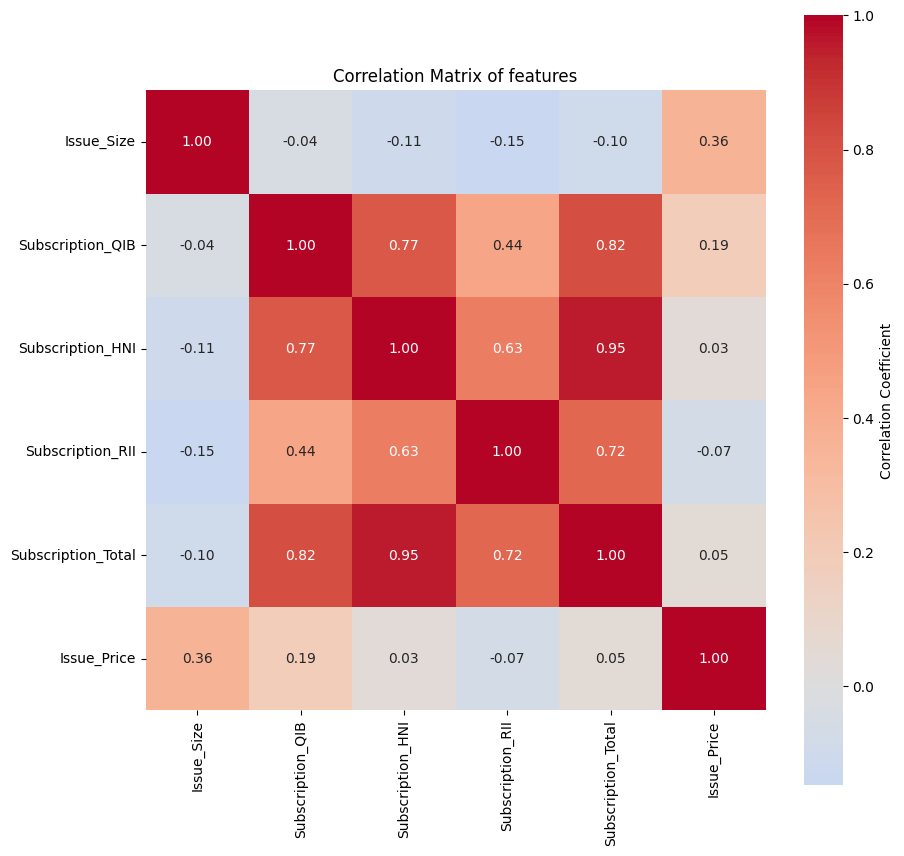

Correlation with IPO Profitability:
Subscription_QIB      0.322197
Subscription_Total    0.281724
Subscription_HNI      0.271228
Subscription_RII      0.235354
Issue_Price           0.040282
Issue_Size            0.004169
Name: Listing_Gains_Profit, dtype: float64


In [17]:
plt.figure(figsize = (10, 10))
sns.heatmap(predictors.corr(), annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', cbar_kws={'label': 'Correlation Coefficient'})
plt.title("Correlation Matrix of features")
plt.show()

# Let's also look at which features correlate most with our target
target_correlations = df[list(predictors.columns) + ['Listing_Gains_Profit']].corr()['Listing_Gains_Profit'].sort_values(ascending=False)
print("Correlation with IPO Profitability:")
print(target_correlations[1:])  # Exclude the target's correlation with itself

Looking at the correlation heatmap, we can see how our features relate to each other, and it reveals some important patterns we need to address.

That big cluster of red in the subscription section shows us strong correlations between the different subscription metrics, especially that `0.95` correlation between `Subscription_HNI` and `Subscription_Total`. This is multicollinearity at work, where features are so similar that they're essentially telling our model the same story multiple times.

The correlation rankings with IPO profitability tell us a different story. Here we see that subscription metrics dominate the top positions, with `Subscription_QIB` leading at `0.32`, while `Issue_Price` (`0.04`) and `Issue_Size` show very weak relationships with success.

Now, you might think we should just dump those poorly correlated features, but that would be a mistake. Correlation only captures linear relationships between individual features and our target. Our neural network can find much more complex patterns, especially interactions between features. Maybe small IPOs behave completely differently than large ones when they get high subscription rates. Maybe pricing matters more for certain types of companies. These nuanced patterns won't show up in simple correlation calculations, but they could be exactly what makes our model successful.

That all said, we do need to tackle that multicollinearity problem. Since `Subscription_Total` is literally just the sum of the individual subscription components, we'll drop it and keep the individual metrics instead. This preserves the detailed information about different investor types while eliminating the redundancy that could confuse our model.

Our final `feature_columns` set gives us the best of both worlds: `Subscription_QIB`, `Subscription_HNI`, `Subscription_RII`, `Issue_Price`, `Issue_Size`. Five focused features that each bring unique information to help our model understand what drives IPO success.

In [18]:
feature_columns = ['Subscription_QIB', 'Subscription_HNI', 'Subscription_RII', 'Issue_Price', 'Issue_Size'] 

## Data Splitting and Scaling
With your target split at 54.5% profitable vs 45.5% non-profitable, you want to make sure each of your data splits maintains this same proportion. You'll also need to handle feature scaling correctly to avoid data leakage, which could give you misleadingly optimistic results during development.

In [19]:
# Create the Feature Variable for training
X = df[feature_columns]

# Target Variable
y = df['Listing_Gains_Profit']

# Split the dataset into Training, Testing, and Validation Set.
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size = 0.2, shuffle = True,random_state = 42, stratify = y)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size = 0.25, shuffle = True,random_state = 42, stratify = y_temp)

print(y_train.value_counts(normalize = True))
print(y_test.value_counts(normalize = True))
print(y_val.value_counts(normalize = True))

Listing_Gains_Profit
1    0.550265
0    0.449735
Name: proportion, dtype: float64
Listing_Gains_Profit
1    0.539683
0    0.460317
Name: proportion, dtype: float64
Listing_Gains_Profit
1    0.539683
0    0.460317
Name: proportion, dtype: float64


In [20]:
# Scale the Dataset
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

X_train_scaled = pd.DataFrame(X_train_scaled, columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns = X_test.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns = X_val.columns)

In [21]:
# Check the dataset
X_train_scaled.head()

,Subscription_QIB,Subscription_HNI,Subscription_RII,Issue_Price,Issue_Size
0,-0.624043,-0.492709,-0.392698,0.780951,-0.038937
1,-0.557446,-0.515196,-0.418401,-0.974163,-0.296838
2,-0.273066,-0.467889,-0.456016,0.529822,0.370478
3,-0.648111,-0.507064,-0.286751,-0.764888,-0.539761
4,1.319182,-0.441230,-0.252271,-0.251469,0.147171


## Data Pipeline & PyTorch Setup
Loading the Dataset for Pytorch setup

In [22]:
# Loading the feature Dataset into PyTorch tensor.
X_train_t = torch.tensor(X_train_scaled.values, dtype = torch.float32)
X_test_t = torch.tensor(X_test_scaled.values, dtype = torch.float32)
X_val_t = torch.tensor(X_val_scaled.values, dtype = torch.float32)

# Loading the target variable into PyTorch tensor.
y_test_t = torch.tensor(y_test.values, dtype = torch.float32)
y_train_t = torch.tensor(y_train.values, dtype = torch.float32)
y_val_t = torch.tensor(y_val.values, dtype = torch. float32)

print("Tensor shapes:")
print(f"  X_train: {X_train_t.shape}")
print(f"  y_train: {y_train_t.shape}")
print(f"  X_val: {X_val_t.shape}")
print(f"  y_val: {y_val_t.shape}")
print(f"  X_test: {X_test_t.shape}")
print(f"  y_test: {y_test_t.shape}")

Tensor shapes:
  X_train: torch.Size([189, 5])
  y_train: torch.Size([189])
  X_val: torch.Size([63, 5])
  y_val: torch.Size([63])
  X_test: torch.Size([63, 5])
  y_test: torch.Size([63])


In [23]:
# Create a Tensor dataset
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size = 16, shuffle = True)

# Loading the Test Dataset
test_dataset = TensorDataset(X_test_t, y_test_t)
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle = False)

# Loading the Validation Dataset
val_dataset = TensorDataset(X_val_t, y_val_t)
val_loader = DataLoader(val_dataset, batch_size = 16, shuffle = False)

print("DataLoaders created:")
print(f"  Training batches: {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

DataLoaders created:
  Training batches: 12
  Validation batches: 4
  Test batches: 4


## Model Architecture Design

In [91]:
# Designing a squential model to fit the data.

model = nn.Sequential(
    nn.Linear(X_train_t.shape[1], 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
    nn.Sigmoid()
)

print(model)

    

Sequential(
  (0): Linear(in_features=5, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=1, bias=True)
  (5): Sigmoid()
)


In [92]:
for name, param in model.named_parameters():
    print(f'{name}:{param.shape}')
    
total_params = sum(param.numel() for param in model.parameters())
print(f"Total Parameter:{total_params}")

0.weight:torch.Size([32, 5])
0.bias:torch.Size([32])
2.weight:torch.Size([16, 32])
2.bias:torch.Size([16])
4.weight:torch.Size([1, 16])
4.bias:torch.Size([1])
Total Parameter:737


## Training Implementation
Now it's time to train your network and see how well it learns to predict IPO success.

In [93]:
# setup the loss criterion
criterion = nn.BCELoss()

#setup the optimizer
optimizer = optim.Adam(model.parameters(), lr = 0.005)
epochs = 100

training_accuracies = []
validation_accuracies = []
# setup the training
model.train()
for i in range(epochs):
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X).squeeze()
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
    with torch.no_grad():
        train_outputs = model(X_train_t).squeeze()
        train_predictions = (train_outputs > 0.5).float()
        train_loss = (train_predictions == y_train_t).float().mean().item() * 100
        training_accuracies.append(train_loss)

        val_outputs = model(X_val_t).squeeze()
        val_prediction = (val_outputs > 0.5).float()
        val_loss = (val_prediction == y_val_t).float().mean().item() * 100
        validation_accuracies.append(val_loss)



# print the traning and validation accuracy
print(f"Final training accuracy: {training_accuracies[-1]:.1f}%")
print(f"Final validation accuracy: {validation_accuracies[-1]:.1f}%")
        


Final training accuracy: 82.5%
Final validation accuracy: 68.3%


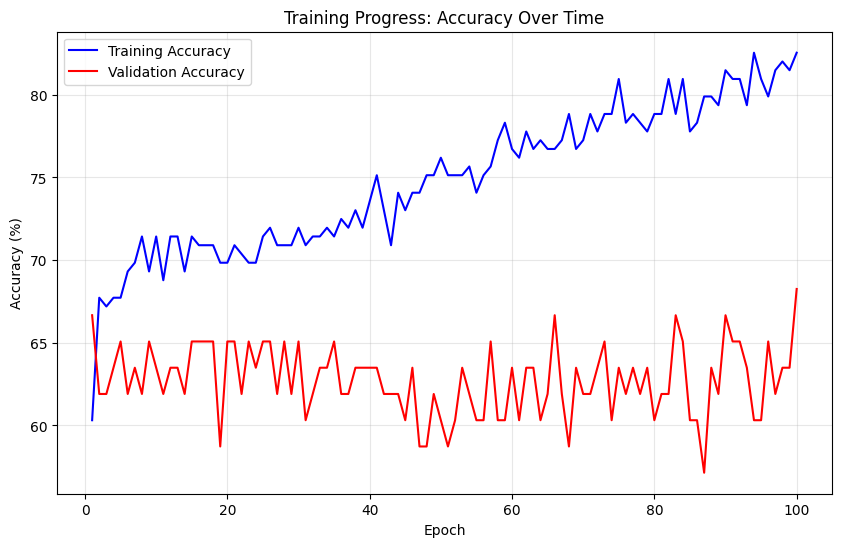

Best validation accuracy: 68.3% (achieved at epoch 100)
Final gap between training and validation: 14.3 percentage points


In [94]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), training_accuracies, label='Training Accuracy', color='blue')
plt.plot(range(1, epochs + 1), validation_accuracies, label='Validation Accuracy', color='red')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training Progress: Accuracy Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Let's also see the best performance we achieved
best_val_accuracy = max(validation_accuracies)
best_epoch = validation_accuracies.index(best_val_accuracy) + 1

print(f"Best validation accuracy: {best_val_accuracy:.1f}% (achieved at epoch {best_epoch})")

# Check for potential overfitting
final_gap = training_accuracies[-1] - validation_accuracies[-1]
print(f"Final gap between training and validation: {final_gap:.1f} percentage points")


### Understanding What Just Happened

This plot tells a really clear story about what went wrong during training. Look at how the two lines behave differently. In the first 5-10 epochs, both training and validation accuracy climb together, which is exactly what we want to see. The model is learning genuine patterns that help it perform better on both known and unknown data.

But then something changes. Around epoch 10, the training accuracy keeps climbing steadily toward 80%+ while the validation accuracy hits a ceiling and starts bouncing around erratically between 55% and 65%. This is classic overfitting behavior.

What's happening is that our model has started memorizing specific details about the training IPOs rather than learning general rules about what makes IPOs successful. It gets really good at recognizing the exact companies it trained on, but that knowledge doesn't help with new IPOs it hasn't seen before. The noisy, erratic validation curve after epoch 10 shows the model struggling to apply its overly-specific knowledge to new examples.


## Advanced Regularization & Early Stopping

In [115]:
# Designing a squential model to fit the data.

reg_model = nn.Sequential(
    # First layer
    nn.Linear(X_train_t.shape[1], 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.25),

    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.15),

    nn.Linear(128, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),

    nn.Linear(64, 1),
    nn.Sigmoid()
)

print(reg_model)

    

Sequential(
  (0): Linear(in_features=5, out_features=256, bias=True)
  (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.25, inplace=False)
  (4): Linear(in_features=256, out_features=128, bias=True)
  (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.15, inplace=False)
  (8): Linear(in_features=128, out_features=64, bias=True)
  (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU()
  (11): Linear(in_features=64, out_features=1, bias=True)
  (12): Sigmoid()
)


In [116]:
# setup the training
train_accuracy = []
val_accuracy = []
best_val_accuracy = 0
patience = 20
patience_counter = 0
best_model_state = None

reg_model.train()
for i in range(epochs):
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = reg_model(batch_X).squeeze()
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
    with torch.no_grad():
        train_outputs = reg_model(X_train_t).squeeze()
        train_predictions = (train_outputs > 0.5).float()
        train_acc = (train_predictions == y_train_t).float().mean().item() * 100
        train_accuracy.append(train_acc)

        val_outputs = reg_model(X_val_t).squeeze()
        val_prediction = (val_outputs > 0.5).float()
        val_acc = (val_prediction == y_val_t).float().mean().item() * 100
        val_accuracy.append(val_acc)
        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            best_model_state = copy.deepcopy(reg_model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

reg_model.load_state_dict(best_model_state)
print(f"Loaded best model with validation accuracy: {best_val_accuracy:.1f}%")

Loaded best model with validation accuracy: 57.1%


## Model Evaluation
Let's see how much better our regularized model performs compared to our original overfitting model.

In [117]:
print("Model Comparison:")
print(f"Original model - Final training accuracy: {training_accuracies[-1]:.1f}%")
print(f"Original model - Final validation accuracy: {validation_accuracies[-1]:.1f}%")
print(f"Original model - Gap: {training_accuracies[-1] - validation_accuracies[-1]:.1f} percentage points")

print(f"\nRegularized model - Final training accuracy: {train_accuracy[-1]:.1f}%")
print(f"Regularized model - Final validation accuracy: {val_accuracy[-1]:.1f}%")
print(f"Regularized model - Gap: {train_accuracy[-1] - val_accuracy[-1]:.1f} percentage points")

improvement = val_accuracy[-1] - validation_accuracies[-1]
print(f"\nValidation accuracy improvement: {improvement:+.1f} percentage points")

Model Comparison:
Original model - Final training accuracy: 82.5%
Original model - Final validation accuracy: 68.3%
Original model - Gap: 14.3 percentage points

Regularized model - Final training accuracy: 52.9%
Regularized model - Final validation accuracy: 55.6%
Regularized model - Gap: -2.6 percentage points

Validation accuracy improvement: -12.7 percentage points


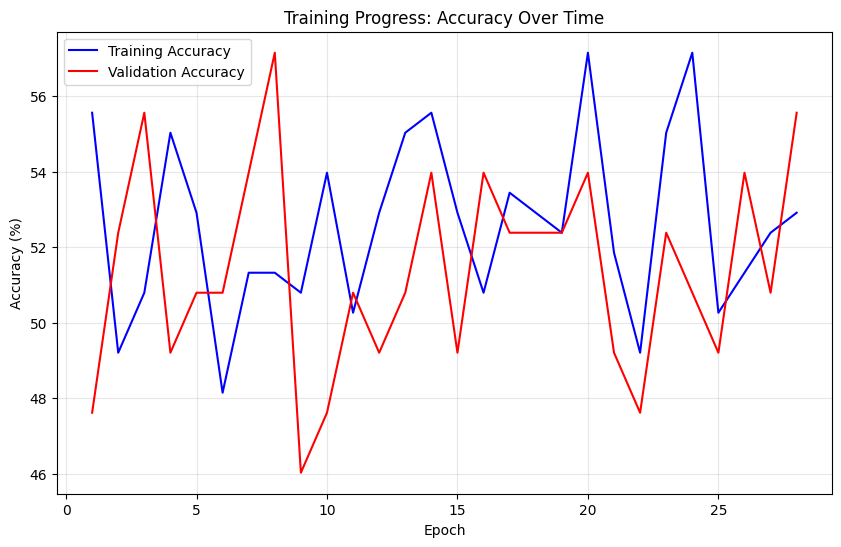

In [118]:
plt.figure(figsize=(10, 6))

# Make x-axis range match accuracy arrays length
epochs_range = range(1, len(train_accuracy) + 1)

plt.plot(epochs_range, train_accuracy, label='Training Accuracy', color='blue')
plt.plot(epochs_range, val_accuracy, label='Validation Accuracy', color='red')

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training Progress: Accuracy Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Visualizing the Improvement

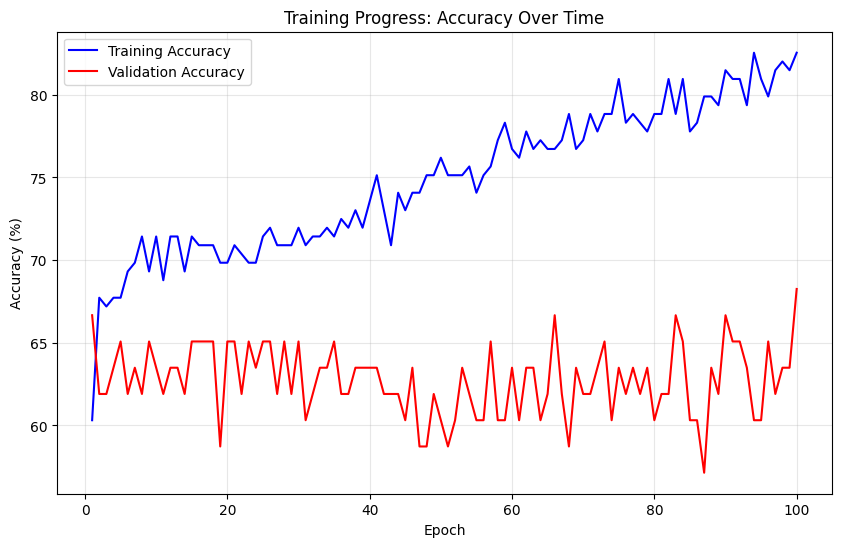

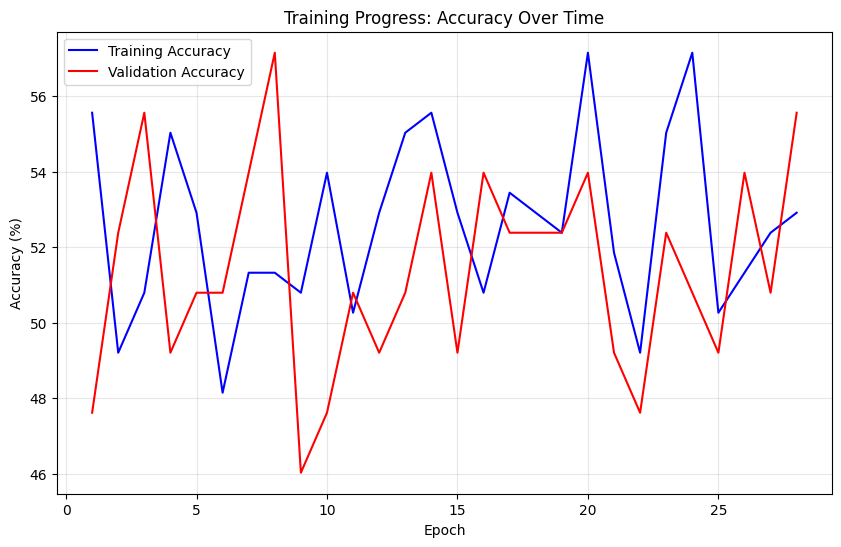

In [119]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), training_accuracies, label='Training Accuracy', color='blue')
plt.plot(range(1, epochs + 1), validation_accuracies, label='Validation Accuracy', color='red')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training Progress: Accuracy Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(10, 6))

# Make x-axis range match accuracy arrays length
epochs_range = range(1, len(train_accuracy) + 1)

plt.plot(epochs_range, train_accuracy, label='Training Accuracy', color='blue')
plt.plot(epochs_range, val_accuracy, label='Validation Accuracy', color='red')

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training Progress: Accuracy Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## The Final Test: How Good Is the Model, Really?

In [124]:
# Time to put our model to the ultimate test
reg_model.eval() 
with torch.no_grad(): 
    # Get predictions on our test set
    test_outputs = model(X_test_t).squeeze()
    test_predictions = (test_outputs > 0.5).float()  

print(f"The regularized model made predictions on {len(y_test_t)} test IPOs")
predicted_profitable = test_predictions.sum().item()
print(f"It predicted {int(predicted_profitable)} would be profitable and {int(len(test_predictions) - predicted_profitable)} would not")
actually_profitable = y_test_t.sum().item()
print(f"In reality, {int(actually_profitable)} were profitable and {int(len(y_test_t) - actually_profitable)} were not")

# Let's see some actual predictions vs reality
print(f"\nFirst 10 test predictions vs actual:")
for i in range(10):
    pred = "Profitable" if test_predictions[i] == 1 else "Not Profitable"
    actual = "Profitable" if y_test_t[i] == 1 else "Not Profitable"
    match = "✓" if test_predictions[i] == y_test_t[i] else "✗"
    print(f"  IPO {i+1}: Predicted {pred}, Actually {actual} {match}")

The regularized model made predictions on 63 test IPOs
It predicted 31 would be profitable and 32 would not
In reality, 34 were profitable and 29 were not

First 10 test predictions vs actual:
  IPO 1: Predicted Not Profitable, Actually Not Profitable ✓
  IPO 2: Predicted Not Profitable, Actually Not Profitable ✓
  IPO 3: Predicted Not Profitable, Actually Not Profitable ✓
  IPO 4: Predicted Profitable, Actually Profitable ✓
  IPO 5: Predicted Profitable, Actually Profitable ✓
  IPO 6: Predicted Profitable, Actually Not Profitable ✗
  IPO 7: Predicted Not Profitable, Actually Profitable ✗
  IPO 8: Predicted Profitable, Actually Not Profitable ✗
  IPO 9: Predicted Profitable, Actually Not Profitable ✗
  IPO 10: Predicted Profitable, Actually Profitable ✓


##  Breaking Down Mistakes with a Confusion Matrix

In [125]:
# Create our confusion matrix
cm = confusion_matrix(y_test_t.numpy(), test_predictions.numpy())
print("Confusion Matrix:")
print("                 Predicted")
print("                Not Profitable  Profitable")
print(f"Actual Not Prof        {cm[0,0]}          {cm[0,1]}")
print(f"Actual Profitable      {cm[1,0]}          {cm[1,1]}")

# Extract the four key numbers
tn, fp, fn, tp = cm[0,0].item(), cm[0,1].item(), cm[1,0].item(), cm[1,1].item()

print(f"\nBreaking this down:")
print(f"True Negatives (TN): {tn} - Correctly predicted NOT profitable")
print(f"False Positives (FP): {fp} - Wrongly predicted profitable (Type I error)")
print(f"False Negatives (FN): {fn} - Wrongly predicted NOT profitable (Type II error)")
print(f"True Positives (TP): {tp} - Correctly predicted profitable")

print(f"\nOut of {tn + fp + fn + tp} total predictions:")
print(f"We got {tn + tp} right and {fp + fn} wrong")

Confusion Matrix:
                 Predicted
                Not Profitable  Profitable
Actual Not Prof        19          10
Actual Profitable      13          21

Breaking this down:
True Negatives (TN): 19 - Correctly predicted NOT profitable
False Positives (FP): 10 - Wrongly predicted profitable (Type I error)
False Negatives (FN): 13 - Wrongly predicted NOT profitable (Type II error)
True Positives (TP): 21 - Correctly predicted profitable

Out of 63 total predictions:
We got 40 right and 23 wrong


## The Business Metrics That Actually Matter¶

In [126]:
# Calculate precision: Of all our "profitable" predictions, how many were right?
precision = tp / (tp + fp)

# Calculate recall: Of all actually profitable IPOs, how many did we find?
recall = tp / (tp + fn)

print("Key Business Metrics:")
print(f"Precision: {precision:.3f} ({precision*100:.1f}%)")
print(f"  → When we predict 'profitable', we're right {precision*100:.1f}% of the time")

print(f"Recall: {recall:.3f} ({recall*100:.1f}%)")
print(f"  → We successfully identify {recall*100:.1f}% of all profitable IPOs")

# Test accuracy - the overall percentage we got right
test_accuracy = (tn + tp) / (tn + fp + fn + tp) * 100
print(f"\nTest Accuracy: {test_accuracy:.1f}%")
print(f"Validation Accuracy (best): {best_val_accuracy:.1f}%")

accuracy_diff = abs(test_accuracy - best_val_accuracy)
if accuracy_diff < 3:
    print(f"✅ Excellent! Test and validation accuracies are very close ({accuracy_diff:.1f}% difference)")
    print("This suggests our model generalizes well to completely new data")
elif accuracy_diff < 7:
    print(f"👍 Good! Test and validation accuracies are reasonably close ({accuracy_diff:.1f}% difference)")
else:
    print(f"🤔 Test accuracy differs from validation by {accuracy_diff:.1f}% - might indicate some overfitting")

Key Business Metrics:
Precision: 0.677 (67.7%)
  → When we predict 'profitable', we're right 67.7% of the time
Recall: 0.618 (61.8%)
  → We successfully identify 61.8% of all profitable IPOs

Test Accuracy: 63.5%
Validation Accuracy (best): 57.1%
👍 Good! Test and validation accuracies are reasonably close (6.3% difference)


## What This Means for Investment Decisions

In [127]:
print("Business Impact Analysis:")
print("="*50)

print(f"\nFalse Positives ({fp} cases): We predicted profitable, but IPO lost money")
print("💸 Business impact: We invest in bad IPOs and lose money")
print("💡 This hurts our returns directly - we put money into losing investments")

print(f"\nFalse Negatives ({fn} cases): We predicted not profitable, but IPO made money")
print("😞 Business impact: We miss out on good investment opportunities")
print("💡 This is opportunity cost - we could have made money but didn't")

print(f"\nFor a typical investment firm:")
if fp > fn:
    print("⚠️ We're making more 'bad investment' errors than 'missed opportunity' errors")
    print("Consider raising our threshold above 0.5 to be more selective")
elif fn > fp:
    print("⚠️ We're missing more opportunities than we're making bad investments")
    print("Consider lowering our threshold below 0.5 to catch more profitable IPOs")
else:
    print("✅ We have a balanced error profile")

print(f"\nPrecision tells our clients: 'When we recommend an IPO, we're right {precision*100:.1f}% of the time'")
print(f"Recall tells us: 'We find {recall*100:.1f}% of all the profitable opportunities in the market'")

# Overall assessment
if precision > 0.65 and recall > 0.65:
    print(f"\n🎉 Solid performance! Decent precision AND decent recall")
elif precision > 0.7:
    print(f"\n🎯 Conservative but reliable - when we say buy, we're usually right")
elif recall > 0.7:
    print(f"\n🔍 Great at finding opportunities - we don't miss many profitable IPOs")
else:
    print(f"\n📈 Room for improvement, but this is a solid foundation to build on")

print(f"\nBottom line: Our model correctly predicts IPO outcomes {test_accuracy:.1f}% of the time")

Business Impact Analysis:

False Positives (10 cases): We predicted profitable, but IPO lost money
💸 Business impact: We invest in bad IPOs and lose money
💡 This hurts our returns directly - we put money into losing investments

False Negatives (13 cases): We predicted not profitable, but IPO made money
😞 Business impact: We miss out on good investment opportunities
💡 This is opportunity cost - we could have made money but didn't

For a typical investment firm:
⚠️ We're missing more opportunities than we're making bad investments
Consider lowering our threshold below 0.5 to catch more profitable IPOs

Precision tells our clients: 'When we recommend an IPO, we're right 67.7% of the time'
Recall tells us: 'We find 61.8% of all the profitable opportunities in the market'

📈 Room for improvement, but this is a solid foundation to build on

Bottom line: Our model correctly predicts IPO outcomes 63.5% of the time
